In [6]:
import pandas as pd
import numpy as np

series = pd.read_parquet('/kaggle/input/competitions/child-mind-institute-detect-sleep-states/train_series.parquet')
events = pd.read_csv('/kaggle/input/competitions/child-mind-institute-detect-sleep-states/train_events.csv')

print("Series shape:", series.shape)
print("Events shape:", events.shape)

print("\nSeries columns:", series.columns)
print("Events columns:", events.columns)

print("\nSeries head:")
print(series.head())

print("\nEvents head:")
print(events.head())

Series shape: (127946340, 5)
Events shape: (14508, 5)

Series columns: Index(['series_id', 'step', 'timestamp', 'anglez', 'enmo'], dtype='object')
Events columns: Index(['series_id', 'night', 'event', 'step', 'timestamp'], dtype='object')

Series head:
      series_id  step                 timestamp  anglez    enmo
0  038441c925bb     0  2018-08-14T15:30:00-0400  2.6367  0.0217
1  038441c925bb     1  2018-08-14T15:30:05-0400  2.6368  0.0215
2  038441c925bb     2  2018-08-14T15:30:10-0400  2.6370  0.0216
3  038441c925bb     3  2018-08-14T15:30:15-0400  2.6368  0.0213
4  038441c925bb     4  2018-08-14T15:30:20-0400  2.6368  0.0215

Events head:
      series_id  night   event     step                 timestamp
0  038441c925bb      1   onset   4992.0  2018-08-14T22:26:00-0400
1  038441c925bb      1  wakeup  10932.0  2018-08-15T06:41:00-0400
2  038441c925bb      2   onset  20244.0  2018-08-15T19:37:00-0400
3  038441c925bb      2  wakeup  27492.0  2018-08-16T05:41:00-0400
4  038441c925bb    

In [7]:
# Take small subset (VERY IMPORTANT for now)
sample_ids = series['series_id'].unique()[:3]

series_small = series[series['series_id'].isin(sample_ids)].copy()
events_small = events[events['series_id'].isin(sample_ids)].copy()

print(series_small.shape)
print(events_small.shape)

(1511280, 5)
(168, 5)


In [8]:
print(events_small['step'].isna().sum())

78


In [9]:
events_small = events_small.dropna(subset=['step'])

In [10]:
# Initialize labels
series_small['label'] = 0

WINDOW = 10  # range around event

for _, row in events_small.iterrows():
    sid = row['series_id']
    step = int(row['step'])
    
    mask = (
        (series_small['series_id'] == sid) &
        (series_small['step'] >= step - WINDOW) &
        (series_small['step'] <= step + WINDOW)
    )
    
    if row['event'] == 'onset':
        series_small.loc[mask, 'label'] = 1
    else:
        series_small.loc[mask, 'label'] = 2

In [11]:
series_small['label'].value_counts()

label
0    1509390
1        945
2        945
Name: count, dtype: int64

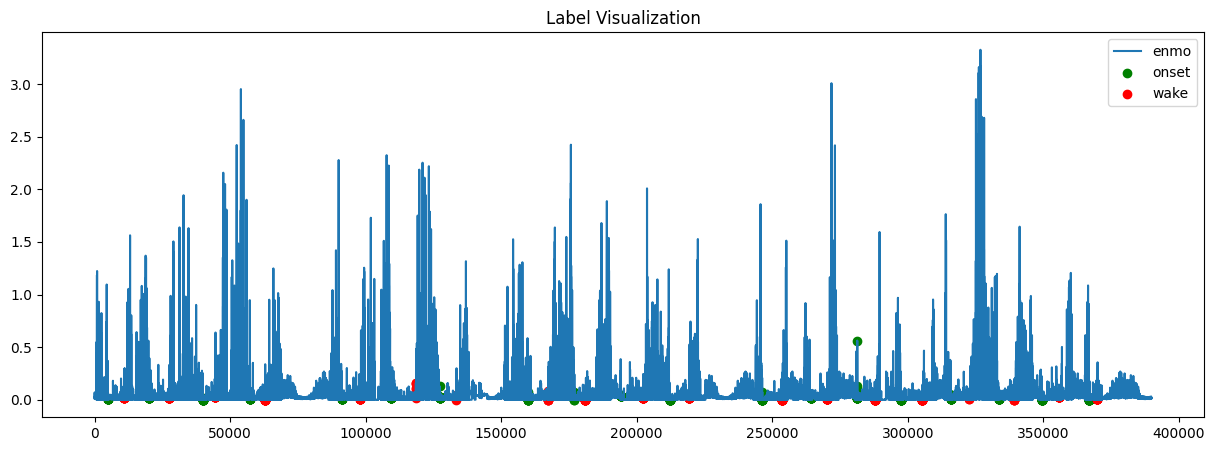

In [12]:
import matplotlib.pyplot as plt

sid = sample_ids[0]
data = series_small[series_small['series_id'] == sid]

plt.figure(figsize=(15,5))
plt.plot(data['step'], data['enmo'], label='enmo')

# plot labels
plt.scatter(data[data['label']==1]['step'],
            data[data['label']==1]['enmo'],
            color='green', label='onset')

plt.scatter(data[data['label']==2]['step'],
            data[data['label']==2]['enmo'],
            color='red', label='wake')

plt.legend()
plt.title("Label Visualization")
plt.show()

In [13]:
WINDOW_SIZE = 200
STRIDE = 50

X = []
y = []

for sid in series_small['series_id'].unique():
    data = series_small[series_small['series_id'] == sid]
    
    features = data[['anglez', 'enmo']].values
    labels = data['label'].values
    
    for i in range(0, len(data) - WINDOW_SIZE, STRIDE):
        X.append(features[i:i+WINDOW_SIZE])
        y.append(labels[i+WINDOW_SIZE-1])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (30215, 200, 2)
y shape: (30215,)


In [14]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(X_train.shape, X_val.shape)

(24172, 200, 2) (6043, 200, 2)


In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Dense, Flatten, Dropout

model = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(200, 2)),
    Conv1D(64, 3, activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 198, 32)        │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 196, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       802,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 809,507 (3.09 MB)

 Trainable params: 809,507 (3.09 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 10s 23ms/step - accuracy: 0.9812 - loss: 0.4866 - val_accuracy: 0.9992 - val_loss: 0.0211
Epoch 2/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9986 - loss: 0.0444 - val_accuracy: 0.9992 - val_loss: 0.0311
Epoch 3/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9982 - loss: 0.0291 - val_accuracy: 0.9992 - val_loss: 0.0159
Epoch 4/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.9985 - loss: 0.0199 - val_accuracy: 0.9992 - val_loss: 0.0209
Epoch 5/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.9989 - loss: 0.0128 - val_accuracy: 0.9992 - val_loss: 0.0187


In [17]:
preds = model.predict(X_val)
pred_labels = preds.argmax(axis=1)

import numpy as np

print("Predicted label distribution:", np.bincount(pred_labels))
print("Actual label distribution:", np.bincount(y_val))

189/189 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step
Predicted label distribution: [6043]
Actual label distribution: [6038    3    2]


In [18]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(0): np.float64(0.3337890274383087), np.int64(1): np.float64(537.1555555555556), np.int64(2): np.float64(447.6296296296296)}


In [19]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    class_weight=class_weights
)

Epoch 1/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 9s 23ms/step - accuracy: 0.8965 - loss: 27.6033 - val_accuracy: 0.9927 - val_loss: 0.9479
Epoch 2/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9953 - loss: 0.9901 - val_accuracy: 0.9969 - val_loss: 0.9612
Epoch 3/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.9849 - loss: 1.2863 - val_accuracy: 0.9992 - val_loss: 0.9832
Epoch 4/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.9984 - loss: 1.0957 - val_accuracy: 0.9992 - val_loss: 0.7630
Epoch 5/5
378/378 ━━━━━━━━━━━━━━━━━━━━ 10s 27ms/step - accuracy: 0.9672 - loss: 3.8759 - val_accuracy: 0.9894 - val_loss: 1.0005


In [20]:
preds = model.predict(X_val)
pred_labels = preds.argmax(axis=1)

print("Predicted:", np.bincount(pred_labels))
print("Actual:", np.bincount(y_val))

189/189 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Predicted: [5984    0   59]
Actual: [6038    3    2]


In [21]:
unique_ids = series['series_id'].unique()

sample_ids = unique_ids[:10]   # increased from 3 → 10

series_med = series[series['series_id'].isin(sample_ids)].copy()
events_med = events[events['series_id'].isin(sample_ids)].copy()

print(series_med.shape, events_med.shape)

(4838220, 5) (520, 5)


In [29]:
events_med = events_med.dropna(subset=['step'])

In [30]:
series_med['label'] = 0

WINDOW = 10

for _, row in events_med.iterrows():
    sid = row['series_id']
    step = int(row['step'])
    
    mask = (
        (series_med['series_id'] == sid) &
        (series_med['step'] >= step - WINDOW) &
        (series_med['step'] <= step + WINDOW)
    )
    
    if row['event'] == 'onset':
        series_med.loc[mask, 'label'] = 1
    else:
        series_med.loc[mask, 'label'] = 2

In [31]:
series_med['label'].value_counts()

label
0    4832508
1       2856
2       2856
Name: count, dtype: int64

In [32]:
WINDOW_SIZE = 200
STRIDE = 50

X = []
y = []

for sid in series_med['series_id'].unique():
    data = series_med[series_med['series_id'] == sid]
    
    features = data[['anglez', 'enmo']].values
    labels = data['label'].values
    
    for i in range(0, len(data) - WINDOW_SIZE, STRIDE):
        X.append(features[i:i+WINDOW_SIZE])
        y.append(labels[i+WINDOW_SIZE-1])

X = np.array(X)
y = np.array(y)

print("X:", X.shape, "y:", y.shape)

X: (96730, 200, 2) y: (96730,)


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [35]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)

class_weights = dict(zip(classes, weights))
print(class_weights)

{np.int64(0): np.float64(0.333712826881943), np.int64(1): np.float64(496.05128205128204), np.int64(2): np.float64(716.5185185185185)}


In [36]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    class_weight=class_weights
)

Epoch 1/5
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.3081 - loss: 11.1183 - val_accuracy: 0.0104 - val_loss: 1.0667
Epoch 2/5
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.0159 - loss: 1.3415 - val_accuracy: 0.0727 - val_loss: 1.0169
Epoch 3/5
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.1046 - loss: 5.0458 - val_accuracy: 0.0068 - val_loss: 1.1028
Epoch 4/5
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.0245 - loss: 1.0986 - val_accuracy: 0.0110 - val_loss: 1.1120
Epoch 5/5
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.0139 - loss: 1.5354 - val_accuracy: 0.0152 - val_loss: 1.1098


In [37]:
preds = model.predict(X_val)
pred_labels = preds.argmax(axis=1)

print("Predicted:", np.bincount(pred_labels))
print("Actual:", np.bincount(y_val))

605/605 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Predicted: [  287    13 19046]
Actual: [19327    11     8]


In [38]:
class_weights = {
    0: 1.0,
    1: 20.0,
    2: 20.0
}

In [39]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64,
    class_weight=class_weights
)

Epoch 1/5
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 27s 23ms/step - accuracy: 0.7642 - loss: 0.8290 - val_accuracy: 0.9990 - val_loss: 0.0177
Epoch 2/5
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.9955 - loss: 0.5591 - val_accuracy: 0.9990 - val_loss: 0.0274
Epoch 3/5
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.9979 - loss: 0.3762 - val_accuracy: 0.9990 - val_loss: 0.0134
Epoch 4/5
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.9989 - loss: 0.1939 - val_accuracy: 0.9990 - val_loss: 0.0112
Epoch 5/5
1210/1210 ━━━━━━━━━━━━━━━━━━━━ 27s 22ms/step - accuracy: 0.9981 - loss: 0.1791 - val_accuracy: 0.9990 - val_loss: 0.0754


In [40]:
preds = model.predict(X_val)
pred_labels = preds.argmax(axis=1)

print("Predicted:", np.bincount(pred_labels))
print("Actual:", np.bincount(y_val))

605/605 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step
Predicted: [19346]
Actual: [19327    11     8]


In [42]:
event_indices = np.where(y != 0)[0]
normal_indices = np.where(y == 0)[0]

In [43]:
np.random.seed(42)

normal_sample = np.random.choice(
    normal_indices,
    size=len(event_indices) * 5,  # 5x more normal than events
    replace=False
)

In [45]:
selected_indices = np.concatenate([event_indices, normal_sample])

X_bal = X[selected_indices]
y_bal = y[selected_indices]

print("New distribution:", np.bincount(y_bal))

New distribution: [535  63  44]


In [46]:
X_train, X_val, y_train, y_val = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42
)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.8439 - loss: 0.5822 - val_accuracy: 0.7907 - val_loss: 0.7548
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.8321 - loss: 0.6207 - val_accuracy: 0.7907 - val_loss: 0.7539
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8439 - loss: 0.5811 - val_accuracy: 0.7907 - val_loss: 0.7529
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8271 - loss: 0.6353 - val_accuracy: 0.7907 - val_loss: 0.7517
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8313 - loss: 0.6204 - val_accuracy: 0.7907 - val_loss: 0.7505


In [47]:
preds = model.predict(X_val)
pred_labels = preds.argmax(axis=1)

print("Predicted:", np.bincount(pred_labels))
print("Actual:", np.bincount(y_val))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
Predicted: [129]
Actual: [102  17  10]


In [48]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

acc_cnn = accuracy_score(y_val, pred_labels)
prec_cnn = precision_score(y_val, pred_labels, average='weighted')
rec_cnn = recall_score(y_val, pred_labels, average='weighted')
f1_cnn = f1_score(y_val, pred_labels, average='weighted')

print("CNN Metrics:")
print("Accuracy:", acc_cnn)
print("Precision:", prec_cnn)
print("Recall:", rec_cnn)
print("F1 Score:", f1_cnn)

print("\nDetailed Report:\n")
print(classification_report(y_val, pred_labels))

CNN Metrics:
Accuracy: 0.7906976744186046
Precision: 0.6252028123309897
Recall: 0.7906976744186046
F1 Score: 0.6982784657203261

Detailed Report:

              precision    recall  f1-score   support

           0       0.79      1.00      0.88       102
           1       0.00      0.00      0.00        17
           2       0.00      0.00      0.00        10

    accuracy                           0.79       129
   macro avg       0.26      0.33      0.29       129
weighted avg       0.63      0.79      0.70       129



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/m

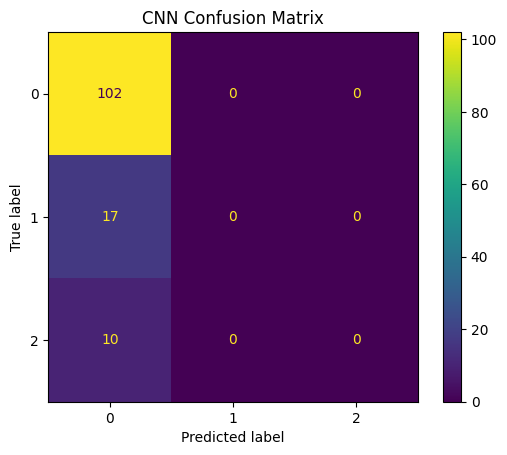

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_val, pred_labels)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("CNN Confusion Matrix")
plt.show()

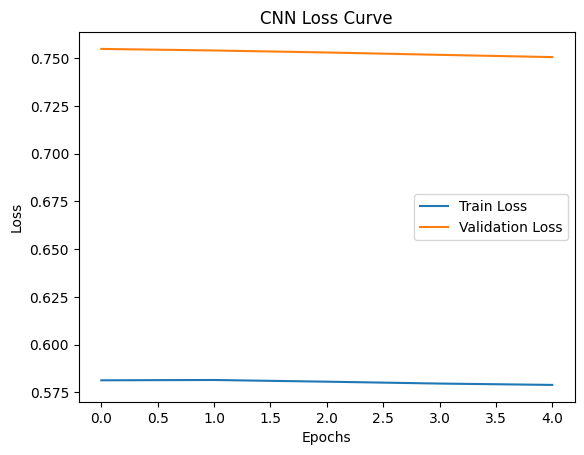

In [50]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('CNN Loss Curve')
plt.legend()
plt.show()

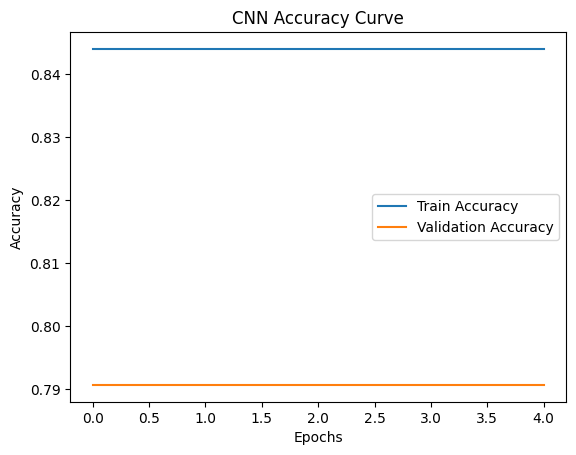

In [51]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('CNN Accuracy Curve')
plt.legend()
plt.show()

In [54]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout

model = Sequential([
    Conv1D(32, 3, activation='relu', input_shape=(200, 2)),
    Conv1D(64, 3, activation='relu'),
    
    LSTM(64, return_sequences=False),
    
    Dense(64, activation='relu'),
    Dropout(0.3),
    
    Dense(3, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 198, 32)        │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 196, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 43,811 (171.14 KB)

 Trainable params: 43,811 (171.14 KB)

 Non-trainable params: 0 (0.00 B)

In [55]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 91ms/step - accuracy: 0.6033 - loss: 0.9047 - val_accuracy: 0.7907 - val_loss: 0.6878
Epoch 2/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.8277 - loss: 0.6004 - val_accuracy: 0.7907 - val_loss: 0.6786
Epoch 3/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.8319 - loss: 0.5706 - val_accuracy: 0.7907 - val_loss: 0.6302
Epoch 4/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8465 - loss: 0.5198 - val_accuracy: 0.7907 - val_loss: 0.6144
Epoch 5/5
9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.8408 - loss: 0.5376 - val_accuracy: 0.7907 - val_loss: 0.6288


In [56]:
preds = model.predict(X_val)
pred_labels = preds.argmax(axis=1)

print("Predicted:", np.bincount(pred_labels))
print("Actual:", np.bincount(y_val))

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Predicted: [129]
Actual: [102  17  10]


In [57]:
WINDOW = 50  # increase this

series_med['label'] = 0

for _, row in events_med.iterrows():
    sid = row['series_id']
    step = int(row['step'])
    
    mask = (
        (series_med['series_id'] == sid) &
        (series_med['step'] >= step - WINDOW) &
        (series_med['step'] <= step + WINDOW)
    )
    
    if row['event'] == 'onset':
        series_med.loc[mask, 'label'] = 1
    else:
        series_med.loc[mask, 'label'] = 2

In [58]:
WINDOW_SIZE = 200
STRIDE = 50

X = []
y = []

for sid in series_med['series_id'].unique():
    data = series_med[series_med['series_id'] == sid]
    
    features = data[['anglez', 'enmo']].values
    labels = data['label'].values
    
    for i in range(0, len(data) - WINDOW_SIZE, STRIDE):
        X.append(features[i:i+WINDOW_SIZE])
        y.append(labels[i+WINDOW_SIZE-1])

X = np.array(X)
y = np.array(y)

print("X:", X.shape)
print("y:", y.shape)
print("Label distribution:", np.bincount(y))

X: (96730, 200, 2)
y: (96730,)
Label distribution: [96186   272   272]


In [59]:
event_indices = np.where(y != 0)[0]
normal_indices = np.where(y == 0)[0]

np.random.seed(42)

normal_sample = np.random.choice(
    normal_indices,
    size=len(event_indices) * 5,
    replace=False
)

selected_indices = np.concatenate([event_indices, normal_sample])

X_bal = X[selected_indices]
y_bal = y[selected_indices]

print("Balanced distribution:", np.bincount(y_bal))

Balanced distribution: [2720  272  272]


In [62]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_bal, y_bal, test_size=0.2, random_state=42
)

In [63]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.8434 - loss: 0.5428 - val_accuracy: 0.7963 - val_loss: 0.6315
Epoch 2/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.8406 - loss: 0.5351 - val_accuracy: 0.7963 - val_loss: 0.6174
Epoch 3/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.8426 - loss: 0.5161 - val_accuracy: 0.7963 - val_loss: 0.6142
Epoch 4/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.8512 - loss: 0.4902 - val_accuracy: 0.7963 - val_loss: 0.6076
Epoch 5/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 65ms/step - accuracy: 0.8521 - loss: 0.4817 - val_accuracy: 0.7963 - val_loss: 0.5711


In [64]:
preds = model.predict(X_val)
pred_labels = preds.argmax(axis=1)

print("Predicted:", np.bincount(pred_labels))
print("Actual:", np.bincount(y_val))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Predicted: [651   2]
Actual: [520  59  74]


In [65]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 198, 32)        │           224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 196, 64)        │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,435 (513.42 KB)

 Trainable params: 43,811 (171.14 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 87,624 (342.29 KB)

In [66]:
print(model.loss)


sparse_categorical_crossentropy


In [72]:
import tensorflow as tf

def focal_loss(gamma=2., alpha=0.75):
    def loss(y_true, y_pred):
        y_true = tf.cast(y_true, tf.int32)
        y_true = tf.one_hot(y_true, depth=3)

        epsilon = 1e-7
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)

        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)

        loss = weight * cross_entropy
        return tf.reduce_mean(tf.reduce_sum(loss, axis=1))
    return loss


model.compile(
    optimizer='adam',
    loss=focal_loss(),
    metrics=['accuracy']
)

In [73]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=5,
    batch_size=64
)

Epoch 1/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 5s 82ms/step - accuracy: 0.8493 - loss: 0.1361 - val_accuracy: 0.7963 - val_loss: 0.1622
Epoch 2/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.8482 - loss: 0.1312 - val_accuracy: 0.7917 - val_loss: 0.1671
Epoch 3/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 74ms/step - accuracy: 0.8488 - loss: 0.1291 - val_accuracy: 0.7948 - val_loss: 0.1673
Epoch 4/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 67ms/step - accuracy: 0.8510 - loss: 0.1250 - val_accuracy: 0.7948 - val_loss: 0.1571
Epoch 5/5
41/41 ━━━━━━━━━━━━━━━━━━━━ 3s 66ms/step - accuracy: 0.8597 - loss: 0.1110 - val_accuracy: 0.7917 - val_loss: 0.1558


In [74]:
preds = model.predict(X_val)
pred_labels = preds.argmax(axis=1)

print("Predicted:", np.bincount(pred_labels))
print("Actual:", np.bincount(y_val))

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step
Predicted: [632  15   6]
Actual: [520  59  74]


In [75]:
# Pick one series_id to test
sid = series_med['series_id'].unique()[0]

data = series_med[series_med['series_id'] == sid]

features = data[['anglez', 'enmo']].values

WINDOW_SIZE = 200
STRIDE = 50

preds = []

steps = []

# Slide over sequence
for i in range(0, len(data) - WINDOW_SIZE, STRIDE):
    window = features[i:i+WINDOW_SIZE]
    window = np.expand_dims(window, axis=0)
    
    pred = model.predict(window, verbose=0)
    label = pred.argmax(axis=1)[0]
    
    preds.append(label)
    steps.append(data['step'].iloc[i+WINDOW_SIZE-1])

# Convert to DataFrame
import pandas as pd

pred_df = pd.DataFrame({
    'step': steps,
    'pred': preds
})

print(pred_df.head())

   step  pred
0   199     0
1   249     0
2   299     0
3   349     0
4   399     0


In [76]:
# Detect onset and wake points
onset_steps = pred_df[pred_df['pred'] == 1]['step']
wake_steps = pred_df[pred_df['pred'] == 2]['step']

print("Predicted onset:", onset_steps.head())
print("Predicted wake:", wake_steps.head())

Predicted onset: 55      2949
161     8249
298    15099
333    16849
356    17999
Name: step, dtype: uint32
Predicted wake: 9        649
70      3699
208    10599
295    14949
301    15249
Name: step, dtype: uint32


In [82]:
def filter_events_by_time(steps, window=20000):
    steps = sorted(steps)
    grouped = []
    current_group = [steps[0]]
    
    for s in steps[1:]:
        if s - current_group[-1] < window:
            current_group.append(s)
        else:
            grouped.append(current_group)
            current_group = [s]
    
    grouped.append(current_group)
    
    # take middle point of each group
    final = [int(np.mean(group)) for group in grouped]
    
    return final

In [83]:
onset_filtered = filter_events_by_time(onset_steps.values)
wake_filtered = filter_events_by_time(wake_steps.values)

print("Final onset:", onset_filtered)
print("Final wake:", wake_filtered)

Final onset: [173861, 372070]
Final wake: [31333, 116039, 182153, 314401]


In [88]:
final_results = []

unique_ids = series['series_id'].unique()

for sid in unique_ids[:10]:
    
    print("Processing:", sid)

    data = series[series['series_id'] == sid].copy()
    events_sid = events[events['series_id'] == sid].copy()

    events_sid = events_sid.dropna(subset=['step'])

    data['label'] = 0
    EVENT_WINDOW = 50

    for _, row in events_sid.iterrows():
        step = int(row['step'])

        mask = (
            (data['step'] >= step - EVENT_WINDOW) &
            (data['step'] <= step + EVENT_WINDOW)
        )

        if row['event'] == 'onset':
            data.loc[mask, 'label'] = 1
        else:
            data.loc[mask, 'label'] = 2

    features = data[['anglez', 'enmo']].values

    WINDOW_SIZE = 200
    STRIDE = 50

    preds = []
    steps = []

    for i in range(0, len(data) - WINDOW_SIZE, STRIDE):
        window = features[i:i+WINDOW_SIZE]
        window = np.expand_dims(window, axis=0)

        pred = model.predict(window, verbose=0)
        label = pred.argmax(axis=1)[0]

        preds.append(label)
        steps.append(data['step'].iloc[i+WINDOW_SIZE-1])

    pred_df = pd.DataFrame({
        'step': steps,
        'pred': preds
    })

    onset_steps = pred_df[pred_df['pred'] == 1]['step'].values
    wake_steps = pred_df[pred_df['pred'] == 2]['step'].values

    def filter_events_by_time(steps, window=20000):
        if len(steps) == 0:
            return []

        steps = sorted(steps)
        grouped = []
        current_group = [steps[0]]

        for s in steps[1:]:
            if s - current_group[-1] < window:
                current_group.append(s)
            else:
                grouped.append(current_group)
                current_group = [s]

        grouped.append(current_group)
        final = [int(np.mean(group)) for group in grouped]

        return final

    onset_final = filter_events_by_time(onset_steps)
    wake_final = filter_events_by_time(wake_steps)

    for s in onset_final:
        final_results.append([sid, 'onset', s])

    for s in wake_final:
        final_results.append([sid, 'wake', s])

final_df = pd.DataFrame(final_results, columns=['series_id', 'event', 'step'])

print(final_df.head())
print("Total predictions:", final_df.shape)

Processing: 038441c925bb
Processing: 03d92c9f6f8a
Processing: 0402a003dae9
Processing: 04f547b8017d
Processing: 05e1944c3818
Processing: 062cae666e2a
Processing: 062dbd4c95e6
Processing: 08db4255286f
Processing: 0a96f4993bd7
Processing: 0cd1e3d0ed95
      series_id  event    step
0  038441c925bb  onset  173861
1  038441c925bb  onset  372070
2  038441c925bb   wake   31333
3  038441c925bb   wake  116039
4  038441c925bb   wake  182153
Total predictions: (86, 3)


In [90]:
final_results = []

unique_ids = series['series_id'].unique()

for sid in unique_ids:

    print("Processing:", sid)

    data = series[series['series_id'] == sid]
    events_sid = events[events['series_id'] == sid].dropna(subset=['step'])

    data = data.copy()
    data['label'] = 0

    EVENT_WINDOW = 50

    for _, row in events_sid.iterrows():
        step = int(row['step'])

        mask = (
            (data['step'] >= step - EVENT_WINDOW) &
            (data['step'] <= step + EVENT_WINDOW)
        )

        data.loc[mask, 'label'] = 1 if row['event'] == 'onset' else 2

    features = data[['anglez', 'enmo']].values
    steps_arr = data['step'].values

    WINDOW_SIZE = 200
    STRIDE = 100

    windows = []
    steps = []

    for i in range(0, len(features) - WINDOW_SIZE, STRIDE):
        windows.append(features[i:i+WINDOW_SIZE])
        steps.append(steps_arr[i+WINDOW_SIZE-1])

    if len(windows) == 0:
        continue

    windows = np.array(windows)

    preds = model.predict(windows, verbose=0)
    pred_labels = preds.argmax(axis=1)

    pred_df = pd.DataFrame({
        'step': steps,
        'pred': pred_labels
    })

    onset_steps = pred_df[pred_df['pred'] == 1]['step'].values
    wake_steps = pred_df[pred_df['pred'] == 2]['step'].values

    def filter_events_by_time(steps, window=20000):
        if len(steps) == 0:
            return []

        steps = sorted(steps)
        grouped = []
        current_group = [steps[0]]

        for s in steps[1:]:
            if s - current_group[-1] < window:
                current_group.append(s)
            else:
                grouped.append(current_group)
                current_group = [s]

        grouped.append(current_group)

        return [int(np.mean(g)) for g in grouped]

    onset_final = filter_events_by_time(onset_steps)
    wake_final = filter_events_by_time(wake_steps)

    for s in onset_final:
        final_results.append([sid, 'onset', s])

    for s in wake_final:
        final_results.append([sid, 'wake', s])

final_df = pd.DataFrame(final_results, columns=['series_id', 'event', 'step'])

print(final_df.head())
print("Total predictions:", final_df.shape)

Processing: 038441c925bb
Processing: 03d92c9f6f8a
Processing: 0402a003dae9
Processing: 04f547b8017d
Processing: 05e1944c3818
Processing: 062cae666e2a
Processing: 062dbd4c95e6
Processing: 08db4255286f
Processing: 0a96f4993bd7
Processing: 0cd1e3d0ed95
Processing: 0ce74d6d2106
Processing: 0cfc06c129cc
Processing: 0d0ad1e77851
Processing: 0dee4fda51c3
Processing: 0ec9fc461819
Processing: 0ef7d94fde99
Processing: 0f572d690310
Processing: 0f9e60a8e56d
Processing: 10469f6765bf
Processing: 1087d7b0ff2e
Processing: 10f8bc1f7b07
Processing: 12d01911d509
Processing: 1319a1935f48
Processing: 137771d19ca2
Processing: 137b99e936ab
Processing: 13b4d6a01d27
Processing: 148471991ffb
Processing: 154fe824ed87
Processing: 16fe2798ed0f
Processing: 1716cd4163b2
Processing: 1762ab70ec76
Processing: 188d4b7cd28b
Processing: 18a0ca03431d
Processing: 18b61dd5aae8
Processing: 1955d568d987
Processing: 1b92be89db4c
Processing: 1c7c0bad1263
Processing: 1d4569cbac0f
Processing: 1e6717d93c1d
Processing: 1f96b9668bdf


In [92]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

preds = model.predict(X_val)
pred_labels = preds.argmax(axis=1)

y_true = y_val
y_pred = pred_labels

print("Shapes:", y_true.shape, y_pred.shape)

print("Accuracy:", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, average='weighted'))
print("Recall:", recall_score(y_true, y_pred, average='weighted'))
print("F1 Score:", f1_score(y_true, y_pred, average='weighted'))

print("\nDetailed Report:\n")
print(classification_report(y_true, y_pred))

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Shapes: (653,) (653,)
Accuracy: 0.7917304747320061
Precision: 0.7233592442540434
Recall: 0.7917304747320061
F1 Score: 0.7233461639280935

Detailed Report:

              precision    recall  f1-score   support

           0       0.81      0.98      0.89       520
           1       0.27      0.07      0.11        59
           2       0.50      0.04      0.07        74

    accuracy                           0.79       653
   macro avg       0.52      0.36      0.36       653
weighted avg       0.72      0.79      0.72       653



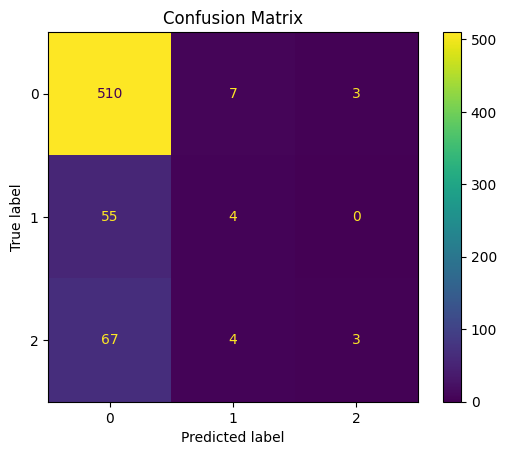

In [93]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

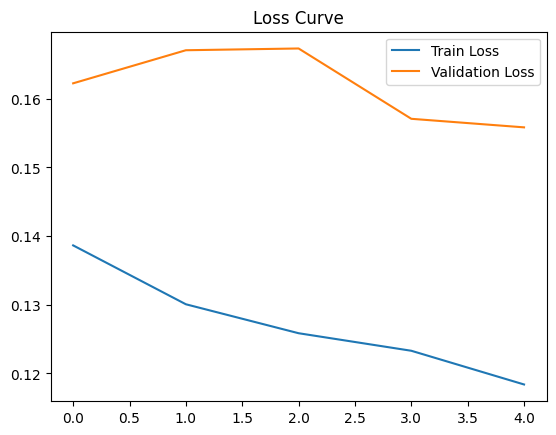

In [94]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

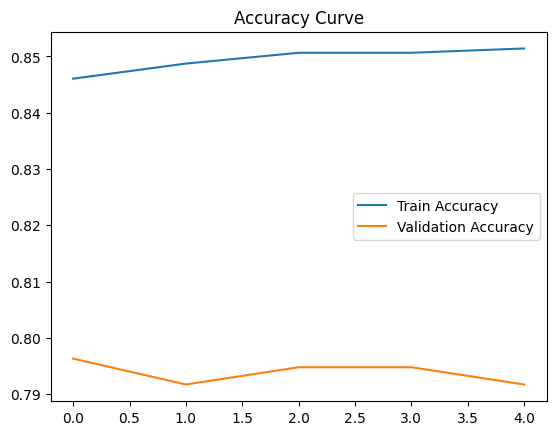

In [95]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()